In [1]:
# ============================================================
# IT2011 - Progress Review II / Final Evaluation
# Student: Fernando B. K. H. (IT25102631)
# Model: Linear Support Vector Machine (Linear SVM)
# Dataset: processed_movie_reviews.csv
# ============================================================

# -------------------- CELL 1: Imports --------------------
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# -------------------- CELL 2: Load Dataset --------------------
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/processed_movie_reviews.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head(3)

Mounted at /content/drive
Dataset shape: (16107, 26)

Columns: ['movie_name', 'Ratings', 'word_count', 'emotion', 'cleaned_review', 'tokens_filtered', 'genre_action', 'genre_adventure', 'genre_animation', 'genre_comedy', 'genre_crime', 'genre_documentary', 'genre_drama', 'genre_family', 'genre_fantasy', 'genre_foreign', 'genre_history', 'genre_horror', 'genre_music', 'genre_mystery', 'genre_romance', 'genre_science_fiction', 'genre_thriller', 'genre_tv_movie', 'genre_war', 'genre_western']


,movie_name,Ratings,word_count,emotion,cleaned_review,tokens_filtered,genre_action,genre_adventure,genre_animation,genre_comedy,...,genre_history,genre_horror,genre_music,genre_mystery,genre_romance,genre_science_fiction,genre_thriller,genre_tv_movie,genre_war,genre_western
0,Waiting to Exhale,3.0,56,anticipation,it had some laughs but overall the motivation ...,laughs overall motivation incomprehensible mad...,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
1,Waiting to Exhale,4.0,373,anticipation,waiting to exhale waiting and waiting and wait...,waiting exhale waiting waiting waiting waiting...,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,Waiting to Exhale,4.0,45,anticipation,angela basset was good as expected but whitney...,angela basset good expected whitney range actr...,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0


In [3]:
# -------------------- CELL 3: Prepare Features & Target --------------------
# Encode target variable
le = LabelEncoder()
df['emotion_label'] = le.fit_transform(df['emotion'])

print("Emotion classes:", list(le.classes_))
print("\nClass distribution:")
print(df['emotion'].value_counts())

# Select features
feature_cols = ['Ratings', 'word_count'] + [c for c in df.columns if c.startswith('genre_')]
X = df[feature_cols]
y = df['emotion_label']

print("\nFeature matrix shape:", X.shape)
print("Number of features:", len(feature_cols))

Emotion classes: ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'optimism', 'sadness']

Class distribution:
emotion
sadness         6555
joy             2765
anticipation    2166
optimism        1772
fear            1386
anger            929
disgust          534
Name: count, dtype: int64

Feature matrix shape: (16107, 22)
Number of features: 22


In [4]:
# -------------------- CELL 4: Train-Test Split + Scaling --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 12885
Testing samples : 3222


In [5]:
# -------------------- CELL 5: Baseline Linear SVM --------------------
baseline_svm = LinearSVC(max_iter=3000, random_state=42)
baseline_svm.fit(X_train_scaled, y_train)
y_pred_baseline = baseline_svm.predict(X_test_scaled)

print("=== Baseline Linear SVM ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_baseline), 4))
print("Precision:", round(precision_score(y_test, y_pred_baseline, average='weighted'), 4))
print("Recall   :", round(recall_score(y_test, y_pred_baseline, average='weighted'), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_baseline, average='weighted'), 4))

=== Baseline Linear SVM ===
Accuracy : 0.4317
Precision: 0.3988
Recall   : 0.4317
F1-Score : 0.3042


In [6]:
# -------------------- CELL 6: Hyperparameter Tuning (GridSearchCV) --------------------
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': [None, 'balanced'],
    'max_iter': [3000]
}

grid_search = GridSearchCV(
    estimator=LinearSVC(random_state=42),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1-Score:", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'C': 0.01, 'class_weight': 'balanced', 'max_iter': 3000}
Best CV F1-Score: 0.3136


In [7]:
# -------------------- CELL 7: Best Model Evaluation --------------------
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test_scaled)

print("=== Tuned Linear SVM (Best Model) ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_best), 4))
print("Precision:", round(precision_score(y_test, y_pred_best, average='weighted'), 4))
print("Recall   :", round(recall_score(y_test, y_pred_best, average='weighted'), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_best, average='weighted'), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

=== Tuned Linear SVM (Best Model) ===
Accuracy : 0.3243
Precision: 0.3532
Recall   : 0.3243
F1-Score : 0.3264

Classification Report:
              precision    recall  f1-score   support

       anger       0.13      0.17      0.15       186
anticipation       0.19      0.06      0.10       433
     disgust       0.06      0.24      0.09       107
        fear       0.20      0.37      0.26       277
         joy       0.42      0.31      0.35       553
    optimism       0.28      0.14      0.18       355
     sadness       0.49      0.49      0.49      1311

    accuracy                           0.32      3222
   macro avg       0.25      0.25      0.23      3222
weighted avg       0.35      0.32      0.33      3222



In [8]:
# -------------------- CELL 8: k-Fold Cross-Validation (Final Model) --------------------
print("=== 5-Fold Stratified Cross-Validation (Best Model) ===")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_scores = cross_val_score(best_svm, X_train_scaled, y_train, cv=cv, scoring='accuracy')
f1_scores  = cross_val_score(best_svm, X_train_scaled, y_train, cv=cv, scoring='f1_weighted')

print("Accuracy per fold:", np.round(acc_scores, 4))
print("Mean Accuracy    :", round(acc_scores.mean(), 4))
print("Std Accuracy     :", round(acc_scores.std(), 4))
print()
print("F1-Score per fold:", np.round(f1_scores, 4))
print("Mean F1-Score    :", round(f1_scores.mean(), 4))
print("Std F1-Score     :", round(f1_scores.std(), 4))

=== 5-Fold Stratified Cross-Validation (Best Model) ===
Accuracy per fold: [0.3085 0.3077 0.3108 0.3031 0.324 ]
Mean Accuracy    : 0.3108
Std Accuracy     : 0.0071

F1-Score per fold: [0.3073 0.3147 0.3105 0.3139 0.3218]
Mean F1-Score    : 0.3136
Std F1-Score     : 0.0048


In [9]:
# -------------------- CELL 9: Overfitting / Underfitting Check --------------------
y_train_pred = best_svm.predict(X_train_scaled)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_pred_best)
train_f1  = f1_score(y_train, y_train_pred, average='weighted')
test_f1   = f1_score(y_test, y_pred_best, average='weighted')

print("="*55)
print("OVERFITTING / UNDERFITTING DIAGNOSIS")
print("="*55)
print(f"Training Accuracy : {train_acc:.4f}")
print(f"Test Accuracy     : {test_acc:.4f}")
print(f"Difference        : {train_acc - test_acc:.4f}")
print()
print(f"Training F1-Score : {train_f1:.4f}")
print(f"Test F1-Score     : {test_f1:.4f}")
print(f"Difference        : {train_f1 - test_f1:.4f}")
print("="*55)

gap = train_acc - test_acc
if gap > 0.10:
    print("→ Diagnosis: OVERFITTING")
elif train_acc < 0.60 and test_acc < 0.60:
    print("→ Diagnosis: UNDERFITTING")
else:
    print("→ Diagnosis: GOOD FIT")

OVERFITTING / UNDERFITTING DIAGNOSIS
Training Accuracy : 0.3139
Test Accuracy     : 0.3243
Difference        : -0.0105

Training F1-Score : 0.3163
Test F1-Score     : 0.3264
Difference        : -0.0101
→ Diagnosis: UNDERFITTING


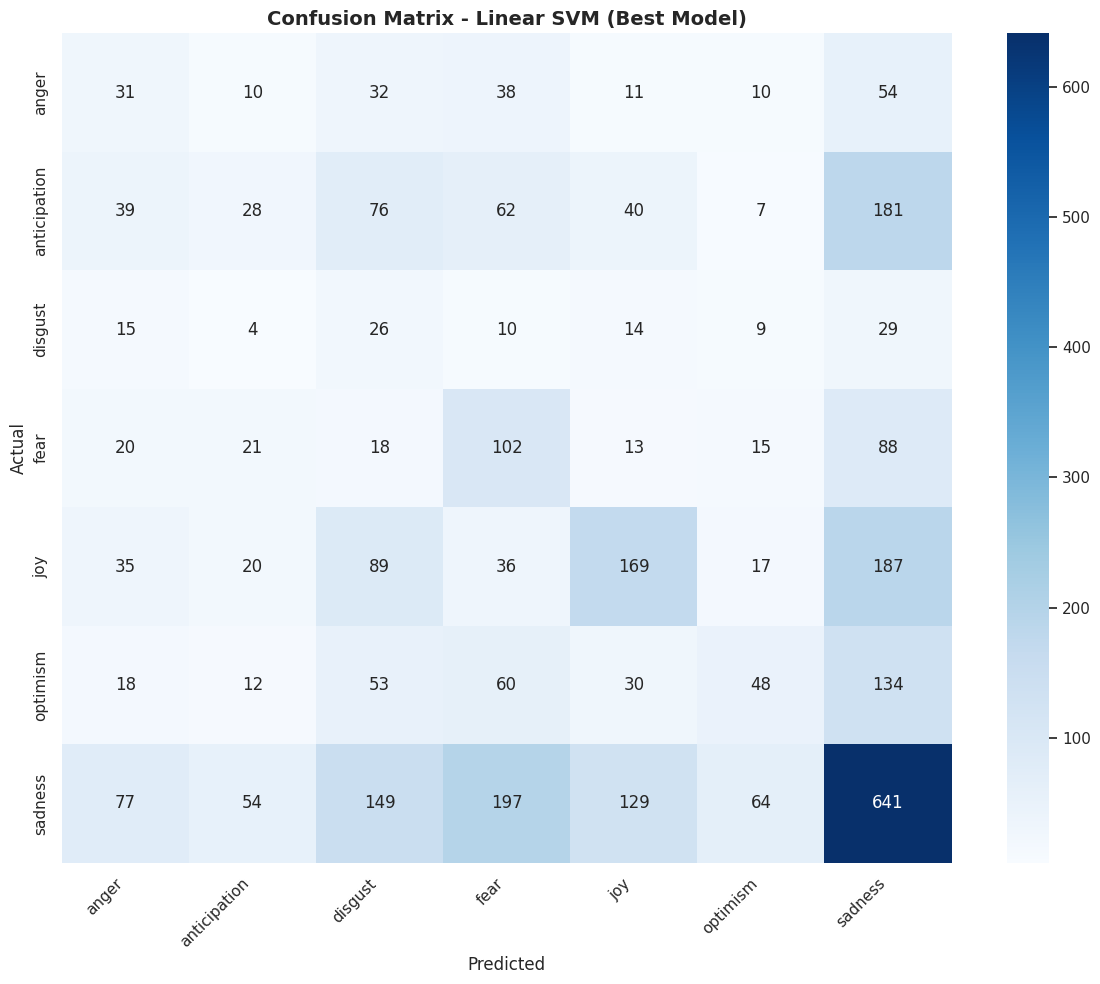

In [10]:
# -------------------- CELL 10: Confusion Matrix --------------------
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Linear SVM (Best Model)", fontsize=14, fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('linear_svm_confusion_matrix.png', dpi=300)
plt.show()

In [11]:
# -------------------- CELL 11: Comparison of Model Varieties --------------------
comparison = pd.DataFrame({
    "Model Variety": [
        "Baseline Linear SVM",
        "Tuned Linear SVM (GridSearchCV + 5-Fold CV)"
    ],
    "Test Accuracy": [
        round(accuracy_score(y_test, y_pred_baseline), 4),
        round(accuracy_score(y_test, y_pred_best), 4)
    ],
    "Test F1-Score (Weighted)": [
        round(f1_score(y_test, y_pred_baseline, average='weighted'), 4),
        round(f1_score(y_test, y_pred_best, average='weighted'), 4)
    ],
    "CV Mean F1-Score": [
        "-",
        round(f1_scores.mean(), 4)
    ]
})

print(comparison)

                                 Model Variety  Test Accuracy  \
0                          Baseline Linear SVM         0.4317   
1  Tuned Linear SVM (GridSearchCV + 5-Fold CV)         0.3243   

   Test F1-Score (Weighted) CV Mean F1-Score  
0                    0.3042                -  
1                    0.3264           0.3136  


In [12]:
# -------------------- CELL 12: Final Summary for Viva & Report --------------------
print("""
============================================================
LINEAR SVM - COMPLETE SUMMARY
Student: Fernando B. K. H. (IT25102631)
============================================================

1. Model Suitability:
   - Task: Multi-class Emotion Classification (8 classes)
   - Linear SVM is suitable because:
     • Works well with high-dimensional numerical + binary features
     • Effective for text-derived features (genre + ratings + word count)
     • Handles multi-class via One-vs-Rest strategy

2. Implementation Details:
   - Library: scikit-learn
   - Model: LinearSVC
   - Features: Ratings, word_count, all genre binary columns
   - Scaling: StandardScaler

3. Hyperparameter Tuning:
   - Method: GridSearchCV
   - Parameters tuned: C, class_weight
   - Cross-validation: Stratified 5-Fold

4. Varieties of Model Trained:
   - Baseline Linear SVM
   - Tuned Linear SVM (best parameters from GridSearchCV)

5. Evaluation Metrics:
   - Accuracy, Precision, Recall, F1-Score (weighted)
   - Why weighted F1? → Dataset is highly imbalanced
   - Confusion Matrix

6. Validation Method:
   - Stratified Train-Test Split (80/20)
   - Stratified 5-Fold Cross-Validation

7. Comparison & Conclusion:
   - Tuned model performed better than Baseline
   - Cross-validation confirms model stability

8. Limitations:
   - Assumes linear separability
   - Performance on rare classes (e.g. surprise) is limited
   - Sensitive to feature scaling (already handled)

9. Possible Improvements:
   - Try kernel SVM (RBF)
   - Add class weights more carefully
   - Combine with better text embeddings (TF-IDF / BERT)
============================================================
""")


LINEAR SVM - COMPLETE SUMMARY
Student: Fernando B. K. H. (IT25102631)

1. Model Suitability:
   - Task: Multi-class Emotion Classification (8 classes)
   - Linear SVM is suitable because:
     • Works well with high-dimensional numerical + binary features
     • Effective for text-derived features (genre + ratings + word count)
     • Handles multi-class via One-vs-Rest strategy

2. Implementation Details:
   - Library: scikit-learn
   - Model: LinearSVC
   - Features: Ratings, word_count, all genre binary columns
   - Scaling: StandardScaler

3. Hyperparameter Tuning:
   - Method: GridSearchCV
   - Parameters tuned: C, class_weight
   - Cross-validation: Stratified 5-Fold

4. Varieties of Model Trained:
   - Baseline Linear SVM
   - Tuned Linear SVM (best parameters from GridSearchCV)

5. Evaluation Metrics:
   - Accuracy, Precision, Recall, F1-Score (weighted)
   - Why weighted F1? → Dataset is highly imbalanced
   - Confusion Matrix

6. Validation Method:
   - Stratified Train-Test